In [16]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yt

In [ ]:
def extract_pelec_data(filepath):
    """
    Parse a PeleC log file (e.g., DebugNR.log) and extract:
        - time
        - XMOM (x‑momentum)
        - x_velocity MIN and MAX
    from each diagnostic block (each block begins with 'TIME = ... MASS').

    Returns a dictionary with:
        'times'          : list of float
        'xmom'           : list of float
        'xvel_min'       : list of float
        'xvel_max'       : list of float
        'xmom_min'       : float (overall min of XMOM)
        'xmom_max'       : float (overall max)
        'xmom_min_time'  : float (time at which XMOM min occurs)
        'xmom_max_time'  : float (time at which XMOM max occurs)
        'xvel_min_min'   : float (overall min of x_velocity min)
        'xvel_min_max'   : float (overall max of x_velocity min)
        'xvel_max_min'   : float (overall min of x_velocity max)
        'xvel_max_max'   : float (overall max of x_velocity max)
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    blocks = []          # list of dicts: {'time', 'xmom', 'xmin', 'xmax'}
    current_block = None
    in_block = False

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Start of a new diagnostic block: "TIME = 1.234e-05 MASS = ..."
        if re.match(r'^TIME\s*=\s*[\d.e+-]+\s+MASS', line):
            if in_block and current_block:
                blocks.append(current_block)
            in_block = True
            time_match = re.search(r'TIME\s*=\s*([\d.e+-]+)', line)
            time_val = float(time_match.group(1)) if time_match else None
            current_block = {'time': time_val, 'xmom': None,
                             'xmin': None, 'xmax': None}

        elif in_block and line.startswith('TIME ='):
            # Parse XMOM or x_velocity lines inside the block
            if 'XMOM' in line:
                m = re.search(r'XMOM\s*=\s*([\d.e+-]+)', line)
                if m:
                    current_block['xmom'] = float(m.group(1))
            elif 'x_velocity' in line:
                m_min = re.search(r'MIN\s*=\s*([\d.e+-]+)', line)
                m_max = re.search(r'MAX\s*=\s*([\d.e+-]+)', line)
                if m_min and m_max:
                    current_block['xmin'] = float(m_min.group(1))
                    current_block['xmax'] = float(m_max.group(1))

        else:
            # End of block
            if in_block and current_block:
                # Append only if all fields are present
                if all(v is not None for v in [current_block['time'],
                                                current_block['xmom'],
                                                current_block['xmin'],
                                                current_block['xmax']]):
                    blocks.append(current_block)
                in_block = False
                current_block = None

    # Append last block if any
    if in_block and current_block:
        if all(v is not None for v in [current_block['time'],
                                        current_block['xmom'],
                                        current_block['xmin'],
                                        current_block['xmax']]):
            blocks.append(current_block)

    # Extract into separate lists
    times = [b['time'] for b in blocks]
    xmom = [b['xmom'] for b in blocks]
    xvel_min = [b['xmin'] for b in blocks]
    xvel_max = [b['xmax'] for b in blocks]

    # Compute overall statistics
    def argmin_max(arr):
        if not arr:
            return None, None, None, None
        min_val = min(arr)
        max_val = max(arr)
        min_idx = arr.index(min_val)
        max_idx = arr.index(max_val)
        return min_val, max_val, min_idx, max_idx

    xmom_min, xmom_max, idx_min_xmom, idx_max_xmom = argmin_max(xmom)
    xmin_min, xmin_max, _, _ = argmin_max(xvel_min)
    xmax_min, xmax_max, _, _ = argmin_max(xvel_max)

    result = {
        'times': times,
        'xmom': xmom,
        'xvel_min': xvel_min,
        'xvel_max': xvel_max,
        'xmom_min': xmom_min,
        'xmom_max': xmom_max,
        'xmom_min_time': times[idx_min_xmom] if idx_min_xmom is not None else None,
        'xmom_max_time': times[idx_max_xmom] if idx_max_xmom is not None else None,
        'xvel_min_min': xmin_min,
        'xvel_min_max': xmin_max,
        'xvel_max_min': xmax_min,
        'xvel_max_max': xmax_max,
    }
    return result

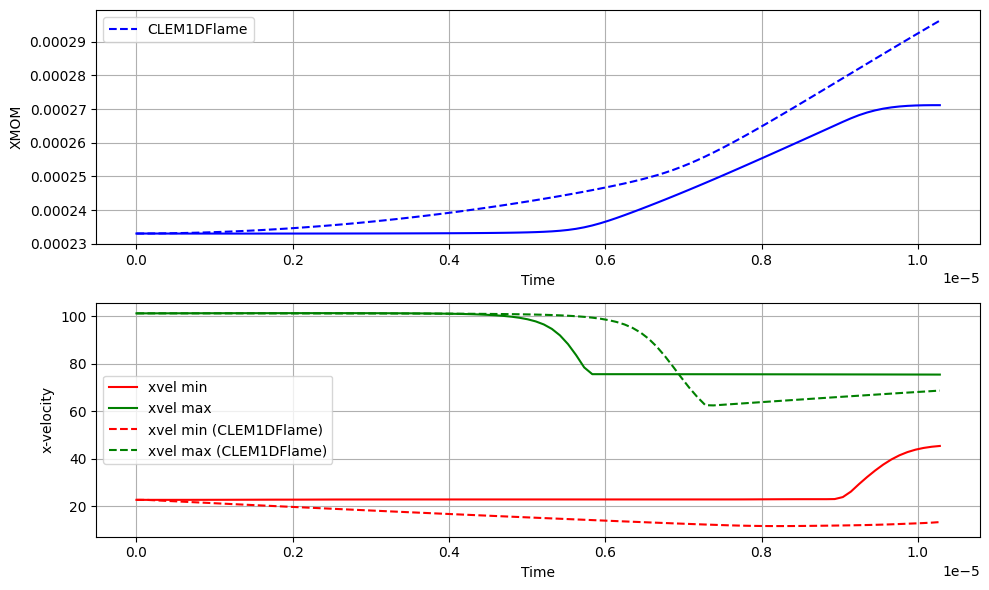

In [15]:
# Extract data
dat_ref = extract_pelec_data("/home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/DebugNR.log")
data_sim = extract_pelec_data("/home/fernando/FPCE/PeleC-CLEM/PeleC/Exec/RegTests/CLEM1DFlame/DebugNR.log")
# Print summary
# Plot
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(dat_ref['times'], dat_ref['xmom'], 'b-')
plt.plot(data_sim['times'], data_sim['xmom'], 'b--', label='CLEM1DFlame')
plt.xlabel('Time')
plt.ylabel('XMOM')
plt.grid(True)
plt.legend()

plt.subplot(2,1,2)
plt.plot(dat_ref['times'], dat_ref['xvel_min'], 'r-', label='xvel min')
plt.plot(dat_ref['times'], dat_ref['xvel_max'], 'g-', label='xvel max')
plt.plot(data_sim['times'], data_sim['xvel_min'], 'r--', label='xvel min (CLEM1DFlame)')
plt.plot(data_sim['times'], data_sim['xvel_max'], 'g--', label='xvel max (CLEM1DFlame)')
plt.xlabel('Time')
plt.ylabel('x-velocity')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Processing: pltFlameNR_00250 vs pltFlameLEM18_00250


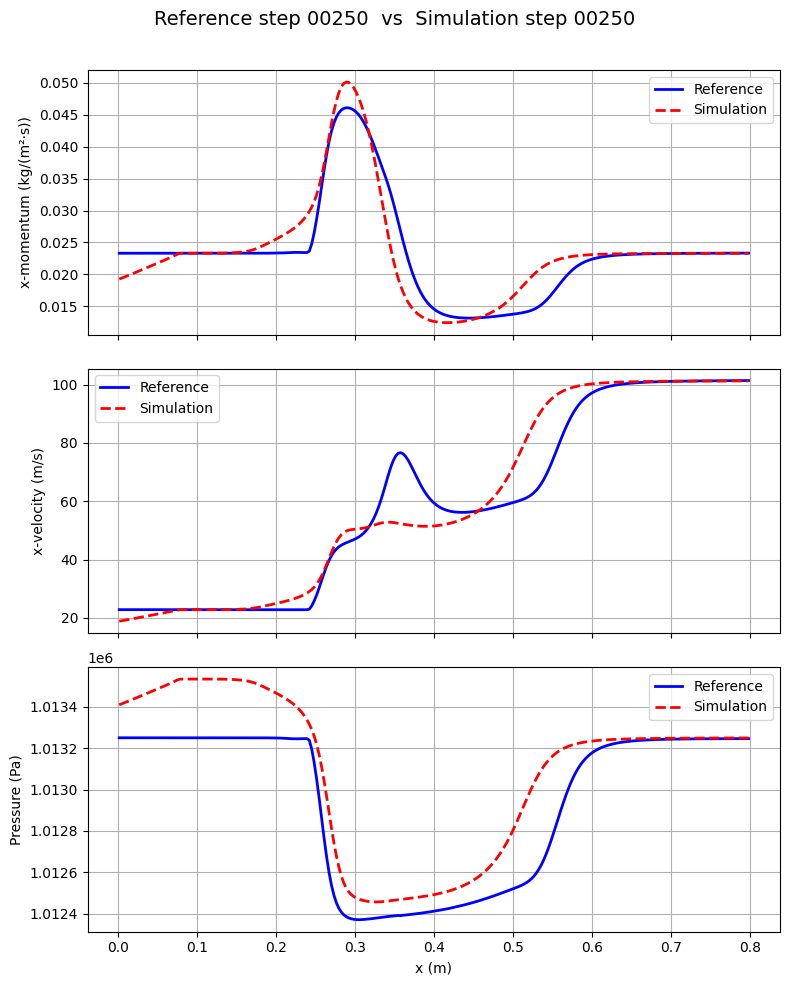

Processing: pltFlameNR_00500 vs pltFlameLEM18_00500


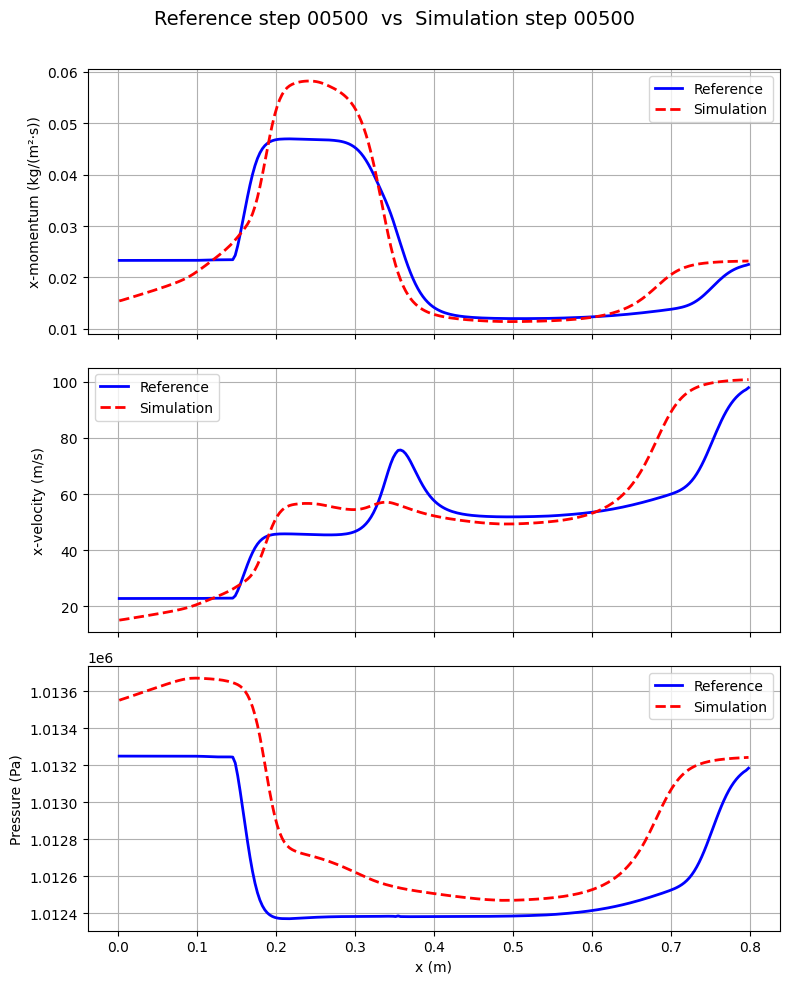

Processing: pltFlameNR_00750 vs pltFlameLEM18_00750


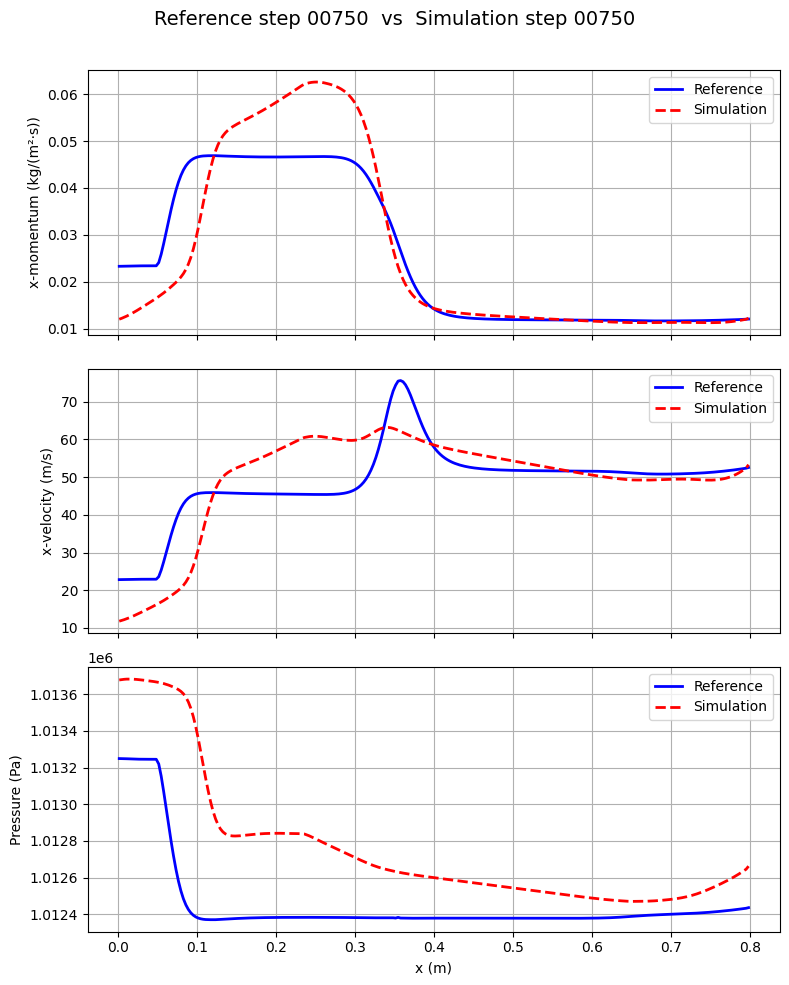

Processing: pltFlameNR_01000 vs pltFlameLEM18_01000


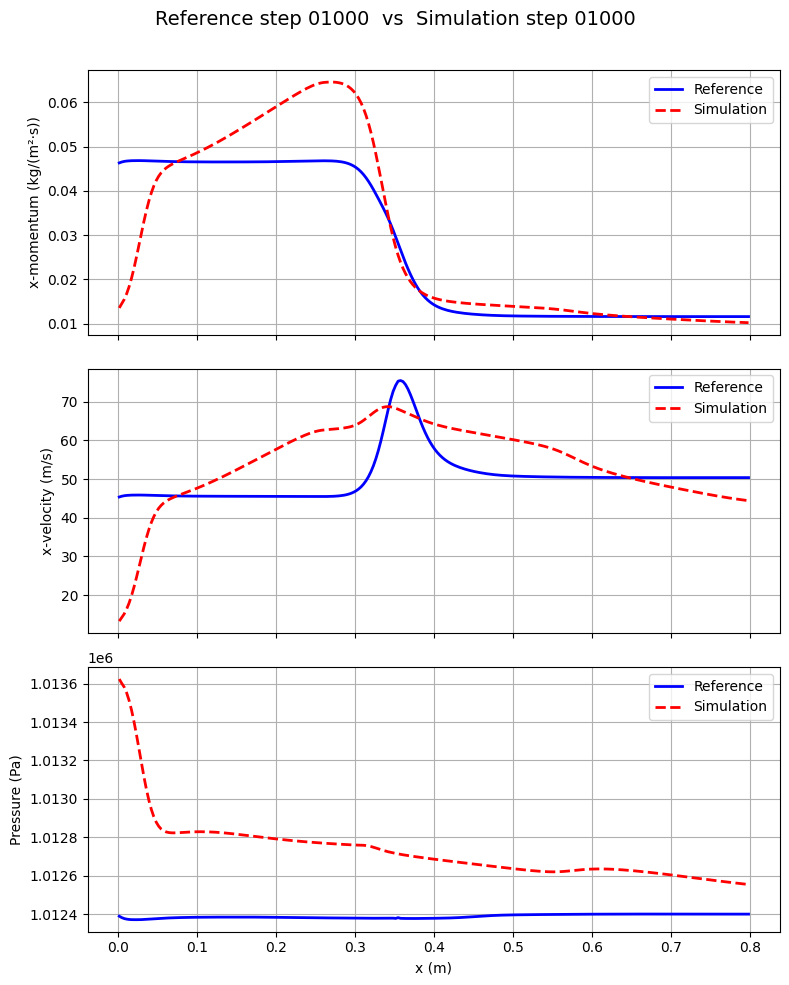

In [19]:
root_reference = "/home/fernando/FPCE/PeleC/Exec/RegTests/1DFlame/CurrentResultsNR"
root_simulation = "CurrentResults"
files_reference = ["pltFlameNR_00250","pltFlameNR_00500","pltFlameNR_00750","pltFlameNR_01000" ]
files_simulation = ["pltFlameLEM18_00250","pltFlameLEM18_00500","pltFlameLEM18_00750","pltFlameLEM18_01000" ]

def extract_xmom(path):
    """Extract x-momentum along x-axis at domain center"""
    yt.set_log_level(50)
    ds = yt.load(path)
    
    # 1D ray along x at the domain mid-line
    c = ds.domain_center
    ray = ds.ortho_ray(0, (c[1], c[2]))
    order = np.argsort(ray["boxlib", "x"])
    
    x = np.array(ray["boxlib", "x"][order])
    xmom = np.array(ray["boxlib", "xmom"][order])  # x-momentum
    pressure = np.array(ray["boxlib", "pressure"][order])  # pressure
    velocity = np.array(ray["velocity_x"][order])  # x-velocity
    
    return x, xmom, pressure, velocity


for ref_file, sim_file in zip(files_reference, files_simulation):
    ref_path = os.path.join(root_reference, ref_file)
    sim_path = os.path.join(root_simulation, sim_file)
    
    print(f"Processing: {ref_file} vs {sim_file}")
    
    # Extract data
    try:
        x_ref, xmom_ref, press_ref, vel_ref = extract_xmom(ref_path)
        x_sim, xmom_sim, press_sim, vel_sim = extract_xmom(sim_path)
    except Exception as e:
        print(f"Error reading {ref_path} or {sim_path}: {e}")
        continue
    
    # Create figure with 3 subplots (stacked vertically)
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    
    # ---- 1. x-momentum ----
    ax = axes[0]
    ax.plot(x_ref, xmom_ref, 'b-', label='Reference', linewidth=2)
    ax.plot(x_sim,  xmom_sim,  'r--', label='Simulation', linewidth=2)
    ax.set_ylabel('x‑momentum (kg/(m²·s))')
    ax.legend(loc='best')
    ax.grid(True)
    
    # ---- 2. x-velocity ----
    ax = axes[1]
    ax.plot(x_ref, vel_ref, 'b-', label='Reference', linewidth=2)
    ax.plot(x_sim,  vel_sim,  'r--', label='Simulation', linewidth=2)
    ax.set_ylabel('x‑velocity (m/s)')
    ax.legend(loc='best')
    ax.grid(True)
    
    # ---- 3. Pressure ----
    ax = axes[2]
    ax.plot(x_ref, press_ref, 'b-', label='Reference', linewidth=2)
    ax.plot(x_sim,  press_sim,  'r--', label='Simulation', linewidth=2)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('Pressure (Pa)')
    ax.legend(loc='best')
    ax.grid(True)
    
    # Add a title with file names (extract step number)
    step_ref = ref_file.split('_')[-1]
    step_sim = sim_file.split('_')[-1]
    fig.suptitle(f'Reference step {step_ref}  vs  Simulation step {step_sim}', fontsize=14)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)   # make room for suptitle
    
    # Save figure (optional)
    # plt.savefig(f'compare_{step_ref}_{step_sim}.png', dpi=150)
    
    # Display
    plt.show()
    